In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive

/content/drive/MyDrive


In [ ]:
cd Colab\ Notebooks

/content/drive/MyDrive/Colab Notebooks


In [ ]:
%cd /content/drive/MyDrive/CPArchPSLinker
!ls

# Shared Utilities (USE FOR ALL BASELINES)

In [ ]:
!pip install --upgrade transformers datasets


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



In [ ]:
import pandas as pd

df = pd.read_excel("Dataset_GitHub_Solutions.xlsx")
# or
# df = pd.read_csv("RQ2_Relevance_Pairs.csv")


# Mandatory Cleaning

In [ ]:
# Keep only required columns
df = df[['commit_id', 'p_text', 'so_id', 's_text', 'label']].copy()

# Drop invalid rows
df.dropna(subset=['p_text', 's_text', 'label'], inplace=True)

# Ensure binary labels
df['label'] = df['label'].astype(int)
df = df[df['label'].isin([0, 1])]

# Reset index
df.reset_index(drop=True, inplace=True)

print(df.shape)
print(df['label'].value_counts())


(1998, 5)
label
1    1014
0     984
Name: count, dtype: int64


In [ ]:
def clean_text(x):
    x = x.lower()
    x = x.replace('\n', ' ')
    x = x.replace('\t', ' ')
    return x.strip()

df['p_text'] = df['p_text'].apply(clean_text)
df['s_text'] = df['s_text'].apply(clean_text)


In [ ]:
def get_pair_text(df):
    X = (df['p_text'] + " [SEP] " + df['s_text']).values
    y = df['label'].values
    return X, y


In [ ]:
def evaluate_binary_classifier(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    P, R, F = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])

        p, r, f, _ = precision_recall_fscore_support(
            y[test_idx], y_pred, average='binary'
        )
        P.append(p); R.append(r); F.append(f)

    return np.mean(P), np.mean(R), np.mean(F)


# GMR Baseline (Similarity-Threshold Model)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sklearn.linear_model import LogisticRegression

In [ ]:


class GMRBaseline:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
        self.clf = LogisticRegression(max_iter=1000)

    def fit(self, X, y):
        # For each pair, join p_text + " [SEP] " + s_text
        X_vec = self.vectorizer.fit_transform(X)
        self.clf.fit(X_vec, y)

    def predict(self, X):
        X_vec = self.vectorizer.transform(X)
        return self.clf.predict(X_vec)


# FITSEA Baseline (Feature-based Supervised Model)

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
def jaccard_similarity(a, b):
    a, b = set(a.split()), set(b.split())
    return len(a & b) / max(1, len(a | b))


In [ ]:
class FITSEABaseline:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(
            stop_words='english',
            max_features=5000
        )
        self.clf = LogisticRegression(max_iter=1000)

    def fit(self, X, y):
        p_texts, s_texts = [], []
        for pair in X:
            p, s = pair.split("[SEP]")
            p_texts.append(p)
            s_texts.append(s)

        tfidf = self.vectorizer.fit_transform(p_texts + s_texts)
        n = len(X)
        p_vecs, s_vecs = tfidf[:n], tfidf[n:]

        cos = cosine_similarity(p_vecs, s_vecs).diagonal()
        jac = [jaccard_similarity(p_texts[i], s_texts[i]) for i in range(n)]

        feats = np.vstack([cos, jac]).T
        self.clf.fit(feats, y)

    def predict(self, X):
        p_texts, s_texts = [], []
        for pair in X:
            p, s = pair.split("[SEP]")
            p_texts.append(p)
            s_texts.append(s)

        tfidf = self.vectorizer.transform(p_texts + s_texts)
        n = len(X)
        p_vecs, s_vecs = tfidf[:n], tfidf[n:]

        cos = cosine_similarity(p_vecs, s_vecs).diagonal()
        jac = [jaccard_similarity(p_texts[i], s_texts[i]) for i in range(n)]

        feats = np.vstack([cos, jac]).T
        return self.clf.predict(feats)


# SVM Baseline (Strong Classical Baseline)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


In [ ]:
class SVMBaseline:
    def __init__(self):
        self.model = Pipeline([
            ('tfidf', TfidfVectorizer(
                stop_words='english',
                max_features=10000
            )),
            ('svm', LinearSVC())
        ])

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


# RoBERTa Baseline (Neural Pair Classifier)

In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch


In [ ]:
class PairDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx])
        }


In [ ]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=2
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Common Utilities (required once)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

def evaluate_with_confusion_matrix(model, X, y, n_splits=5, title="Model"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    ps, rs, fs = [], [], []
    cm_total = np.zeros((2, 2), dtype=int)

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        p, r, f, _ = precision_recall_fscore_support(
            y_test, y_pred, average="binary"
        )
        ps.append(p); rs.append(r); fs.append(f)

        cm = confusion_matrix(y_test, y_pred)
        cm_total += cm

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_total, display_labels=[0, 1])
    disp.plot(cmap="Blues")
    plt.title(f"{title} — Confusion Matrix")
    plt.show()

    return np.mean(ps), np.mean(rs), np.mean(fs), cm_total




#Run Each Baseline

## Example (SVM):

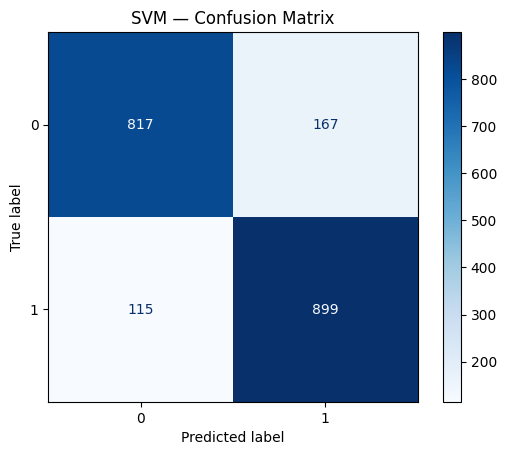

SVM → Precision=0.8438, Recall=0.8866, F1=0.8646
[[817 167]
 [115 899]]


In [ ]:
X, y = get_pair_text(df)

svm = SVMBaseline()
p, r, f, cm = evaluate_with_confusion_matrix(svm, X, y, title="SVM")
print(f"SVM → Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")
print(cm)



Repeat for:

## GMR Baseline

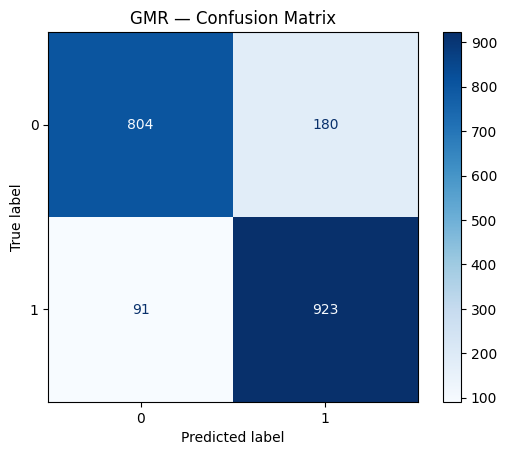

GMR → Precision=0.8371, Recall=0.9103, F1=0.8720
[[804 180]
 [ 91 923]]


In [ ]:
gmr = GMRBaseline()
p, r, f, cm = evaluate_with_confusion_matrix(gmr, X, y, title="GMR")
print(f"GMR → Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")
print(cm)



## FITSEA Baseline

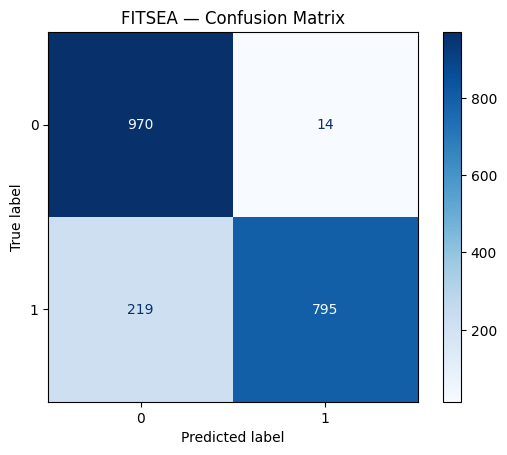

FITSEA → Precision=0.9827, Recall=0.7840, F1=0.8720
[[970  14]
 [219 795]]


In [ ]:
fitsea = FITSEABaseline()
p, r, f, cm = evaluate_with_confusion_matrix(fitsea, X, y, title="FITSEA")
print(f"FITSEA → Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")
print(cm)


# RoBERTa (custom loop)

In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch

class RoBERTaBaseline:
    def __init__(self, model_name="roberta-base"):
        self.tokenizer = RobertaTokenizer.from_pretrained(model_name)
        self.model = RobertaForSequenceClassification.from_pretrained(
            model_name, num_labels=2
        )
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

    def fit(self, X, y, epochs=2, batch_size=8):
        self.model.train()
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=2e-5)

        for _ in range(epochs):
            for i in range(0, len(X), batch_size):
                batch_X = X[i:i+batch_size]
                batch_y = torch.tensor(y[i:i+batch_size]).to(self.device)

                enc = self.tokenizer(
                    list(batch_X),
                    padding=True,
                    truncation=True,
                    max_length=256,
                    return_tensors="pt"
                ).to(self.device)

                out = self.model(**enc, labels=batch_y)
                loss = out.loss
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

    def predict(self, X):
        self.model.eval()
        preds = []

        with torch.no_grad():
            for text in X:
                enc = self.tokenizer(
                    text,
                    return_tensors="pt",
                    truncation=True,
                    max_length=256
                ).to(self.device)

                logits = self.model(**enc).logits
                preds.append(torch.argmax(logits, dim=1).item())

        return np.array(preds)


In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
import torch
from datasets import Dataset

# Prepare text pairs
texts = ["{} [SEP] {}".format(p, s) for p, s in zip(df['p_text'], df['s_text'])]
labels = df['label'].tolist()

dataset = Dataset.from_dict({"text": texts, "label": labels})
dataset = dataset.train_test_split(test_size=0.2, seed=42)

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True, max_length=256)

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

training_args = TrainingArguments(
    output_dir="./roberta_baseline",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    save_strategy="epoch",
    logging_steps=50,
)


from transformers import Trainer, TrainingArguments

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=tokenizer,
)

trainer.train()


Map:   0%|          | 0/1598 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-966884389.py:34: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Step,Training Loss
50,0.610000
100,0.416600
150,0.414600
200,0.342100
250,0.234200
300,0.354000
350,0.344800
400,0.292000
450,0.214700
500,0.255100


TrainOutput(global_step=600, training_loss=0.33108026345570885, metrics={'train_runtime': 410.8722, 'train_samples_per_second': 11.668, 'train_steps_per_second': 1.46, 'total_flos': 630677199697920.0, 'train_loss': 0.33108026345570885, 'epoch': 3.0})

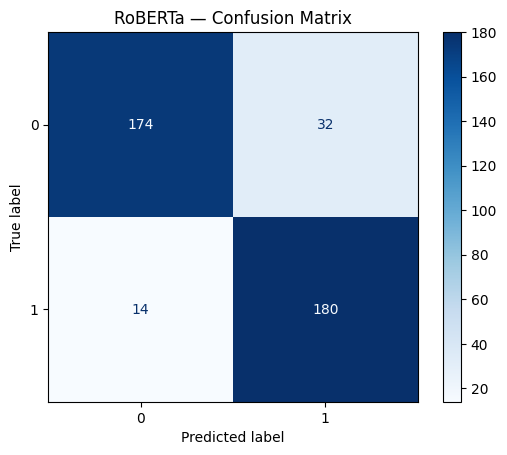

RoBERTa → Precision=0.8491, Recall=0.9278, F1=0.8867
[[174  32]
 [ 14 180]]
RoBERTa → Precision=0.8491, Recall=0.9278, F1=0.8867


In [ ]:
# Predict on test set
preds = trainer.predict(dataset["test"])
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("RoBERTa — Confusion Matrix")
plt.show()

p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
print(f"RoBERTa → Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")
print(cm)


from sklearn.metrics import precision_recall_fscore_support
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
print(f"RoBERTa → Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")


# Remove widgets if the notebook file will be uploaded to GitHub

In [ ]:
import nbformat

# Load your notebook
nb_path = "RQ2_Baselines.ipynb"
nb = nbformat.read(nb_path, as_version=4)

In [ ]:
# Remove the 'widgets' key from notebook metadata if it exists
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

In [ ]:
nbformat.write(nb, "RQ2_Baselines_clean.ipynb")
print("Notebook cleaned and saved as RQ2_Baselines_clean.ipynb")

Notebook cleaned and saved as RQ2_Baselines_clean.ipynb
